# Week 4 — Supervised Learning: Regression Model
**Internship Task**

**Objective:** Build a regression model to predict employee salary using multiple algorithms and evaluate with MAE, MSE, and R² Score.

| Item | Detail |
|---|---|
| Dataset | Synthetic Employee Salary Dataset (1 000 records, 7 features) |
| Target | `Salary` (continuous, USD) |
| Algorithms | Linear Regression · Ridge Regression · Random Forest Regressor |
| Metrics | MAE · MSE · RMSE · R² Score |
| Deliverable | Notebook + evaluation table + Predicted vs Actual graph |


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Dataset Generation

A synthetic **Employee Salary** dataset is generated to mirror real-world HR data.

| Feature | Description |
|---|---|
| `YearsExperience` | Total professional experience (0–20 yrs) |
| `Age` | Employee age (derived from experience) |
| `EducationLevel` | 0=HS · 1=Bachelor · 2=Master · 3=PhD |
| `SkillScore` | Assessed technical skill (40–100) |
| `Department` | Encoded department ID (0–4) |
| `PerformanceRating` | Annual review score (1.0–5.0) |
| `Certifications` | Number of professional certifications |
| **`Salary`** | **Target — annual salary (USD)** |


In [2]:
n = 1_000

years_exp        = np.random.uniform(0, 20, n)
age              = years_exp + np.random.uniform(22, 28, n)
education        = np.random.choice([0, 1, 2, 3], n, p=[0.10, 0.35, 0.40, 0.15])
skill_score      = np.random.uniform(40, 100, n)
department       = np.random.choice([0, 1, 2, 3, 4], n)
perf_rating      = np.random.uniform(1, 5, n)
certifications   = np.random.randint(0, 6, n)

salary = (
    30_000
    + years_exp      * 2_800
    + age            * 150
    + education      * 8_000
    + skill_score    * 200
    + department     * 3_000
    + perf_rating    * 4_000
    + certifications * 2_500
    + np.random.normal(0, 8_000, n)
)
salary = np.clip(salary, 25_000, 200_000)

df = pd.DataFrame({
    "YearsExperience":   np.round(years_exp, 1),
    "Age":               np.round(age).astype(int),
    "EducationLevel":    education,
    "SkillScore":        np.round(skill_score, 1),
    "Department":        department,
    "PerformanceRating": np.round(perf_rating, 2),
    "Certifications":    certifications,
    "Salary":            np.round(salary, 2),
})

print(f"Dataset shape : {df.shape}")
df.head()


Dataset shape : (1000, 8)


,YearsExperience,Age,EducationLevel,SkillScore,Department,PerformanceRating,Certifications,Salary
0,7.5,31,1,80.4,1,4.82,5,133137.13
1,19.0,44,1,87.8,4,1.99,2,137718.71
2,14.6,42,3,55.0,4,4.44,5,159693.54
3,12.0,38,1,77.5,2,1.68,3,112880.00
4,3.1,30,1,74.3,3,4.42,0,82886.14


## 3. Exploratory Data Analysis

In [3]:
print("=== Descriptive Statistics ===")
display(df.describe().round(2))

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)


=== Descriptive Statistics ===


,YearsExperience,Age,EducationLevel,SkillScore,Department,PerformanceRating,Certifications,Salary
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,9.80,34.85,1.60,69.42,2.01,2.99,2.48,113203.43
std,5.84,6.16,0.87,17.19,1.40,1.16,1.71,22308.92
min,0.10,22.00,0.00,40.00,0.00,1.00,0.00,53500.35
25%,4.68,30.00,1.00,54.50,1.00,2.01,1.00,96708.44
50%,9.90,35.00,2.00,69.05,2.00,2.94,2.00,113744.54
75%,14.90,40.00,2.00,84.22,3.00,3.99,4.00,128816.95
max,20.00,47.00,3.00,100.00,4.00,5.00,5.00,173487.88



=== Missing Values ===
YearsExperience      0
Age                  0
EducationLevel       0
SkillScore           0
Department           0
PerformanceRating    0
Certifications       0
Salary               0
dtype: int64

=== Data Types ===
YearsExperience      float64
Age                    int64
EducationLevel         int64
SkillScore           float64
Department             int64
PerformanceRating    float64
Certifications         int32
Salary               float64
dtype: object


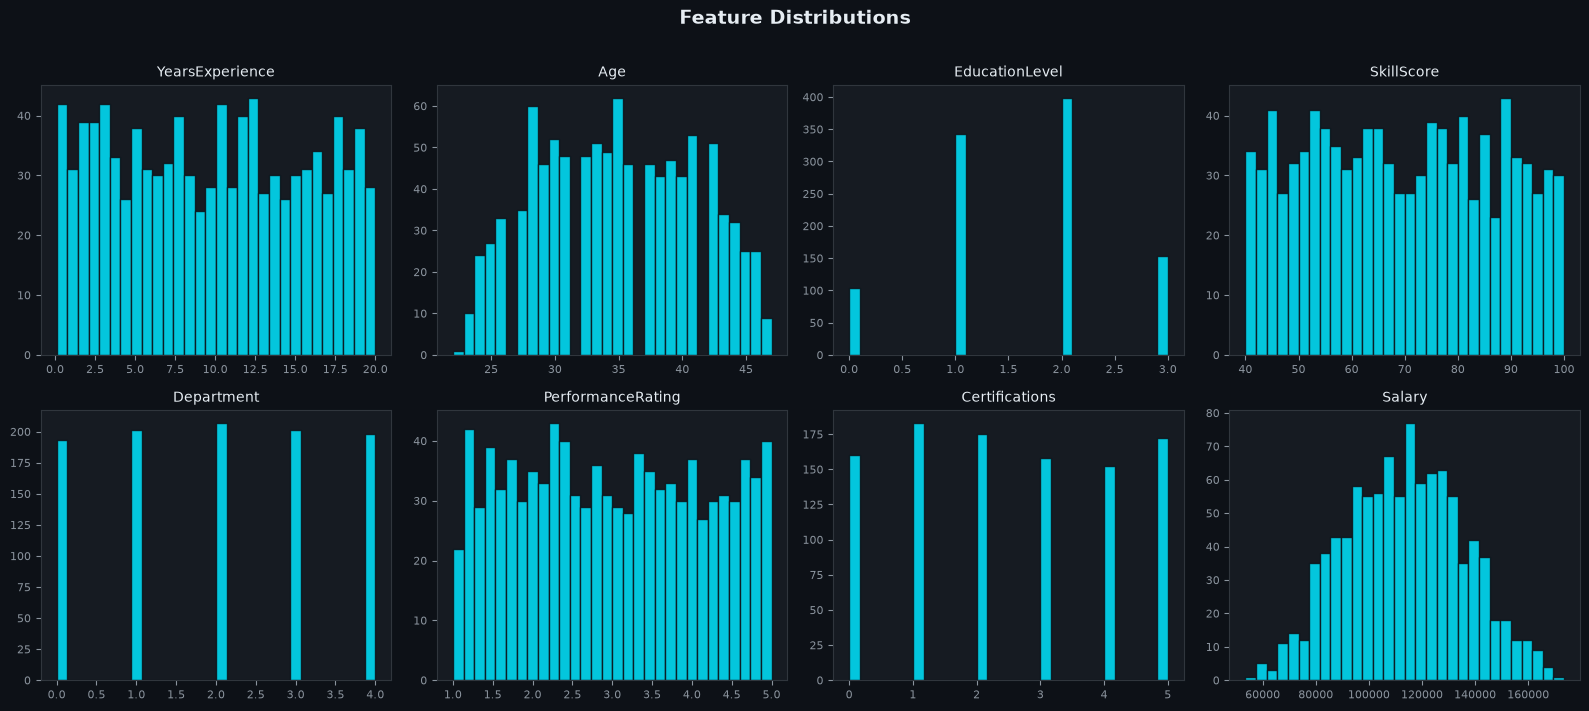

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor("#0D1117")
fig.suptitle("Feature Distributions", color="#E6EDF3", fontsize=14, fontweight="bold", y=1.01)

for ax, col in zip(axes.flat, df.columns):
    ax.set_facecolor("#161B22")
    ax.hist(df[col], bins=30, color="#00E5FF", edgecolor="#0D1117", alpha=0.85)
    ax.set_title(col, color="#E6EDF3", fontsize=10)
    ax.tick_params(colors="#8B949E", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363D")

plt.tight_layout()
plt.show()


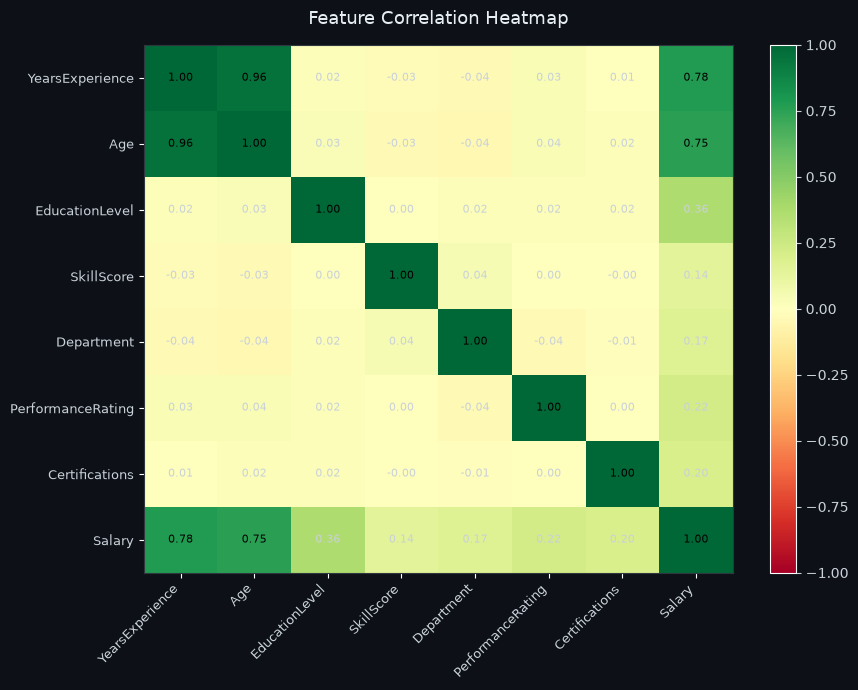

In [5]:
import matplotlib.pyplot as plt

# Correlation heatmap (manual, no seaborn dependency issues)
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")

im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax).ax.tick_params(colors="#C9D1D9")

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", color="#C9D1D9", fontsize=9)
ax.set_yticklabels(labels, color="#C9D1D9", fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black" if abs(val) > 0.4 else "#C9D1D9", fontsize=8)

ax.set_title("Feature Correlation Heatmap", color="#E6EDF3", fontsize=13, pad=15)
for spine in ax.spines.values():
    spine.set_edgecolor("#30363D")

plt.tight_layout()
plt.show()


## 4. Preprocessing & Train/Test Split

In [6]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# StandardScaler for linear models
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")
print(f"Features   : {list(X.columns)}")


Train size : 800
Test  size : 200
Features   : ['YearsExperience', 'Age', 'EducationLevel', 'SkillScore', 'Department', 'PerformanceRating', 'Certifications']


## 5. Model Training

In [7]:
# ── 5.1  Linear Regression ────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
print("Linear Regression trained ✓")


Linear Regression trained ✓


In [8]:
# ── 5.2  Ridge Regression ─────────────────────────────────────
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
print("Ridge Regression trained ✓")


Ridge Regression trained ✓


In [9]:
# ── 5.3  Random Forest Regressor ──────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)          # tree-based: no scaling needed
y_pred_rf = rf.predict(X_test)
print("Random Forest Regressor trained ✓")


Random Forest Regressor trained ✓


## 6. Model Evaluation

In [11]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)":  round(mean_absolute_error(y_true, y_pred), 2),
        "MSE ($²)": round(mean_squared_error(y_true, y_pred), 2),
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R² Score": round(r2_score(y_true, y_pred), 4),
    }

metrics = [
    evaluate("Linear Regression",  y_test, y_pred_lr),
    evaluate("Ridge Regression",   y_test, y_pred_ridge),
    evaluate("Random Forest",      y_test, y_pred_rf),
]

metrics_df = pd.DataFrame(metrics).set_index("Model")
display(metrics_df.style.background_gradient(cmap="Greens", subset=["R² Score"])
                        .background_gradient(cmap="Reds_r", subset=["MAE ($)", "RMSE ($)"]))


,MAE ($),MSE ($²),RMSE ($),R² Score
Model,,,,
Linear Regression,6786.190000,71181122.280000,8436.890000,0.845900
Ridge Regression,6725.400000,70600441.250000,8402.410000,0.847200
Random Forest,8149.740000,99042866.470000,9952.030000,0.785600


In [12]:
# ── 5-Fold Cross-Validation (R²) ──────────────────────────────
for name, model, Xtr, Xts in [
    ("Linear Regression", LinearRegression(), X_train_s, X_test_s),
    ("Ridge Regression",  Ridge(alpha=10.0),  X_train_s, X_test_s),
    ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1), X_train, X_test),
]:
    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring="r2")
    print(f"{name:22s} | CV R² = {cv.mean():.4f} ± {cv.std():.4f}")


Linear Regression      | CV R² = 0.8574 ± 0.0270
Ridge Regression       | CV R² = 0.8566 ± 0.0266
Random Forest          | CV R² = 0.7992 ± 0.0376


## 7. Predicted vs Actual Graph

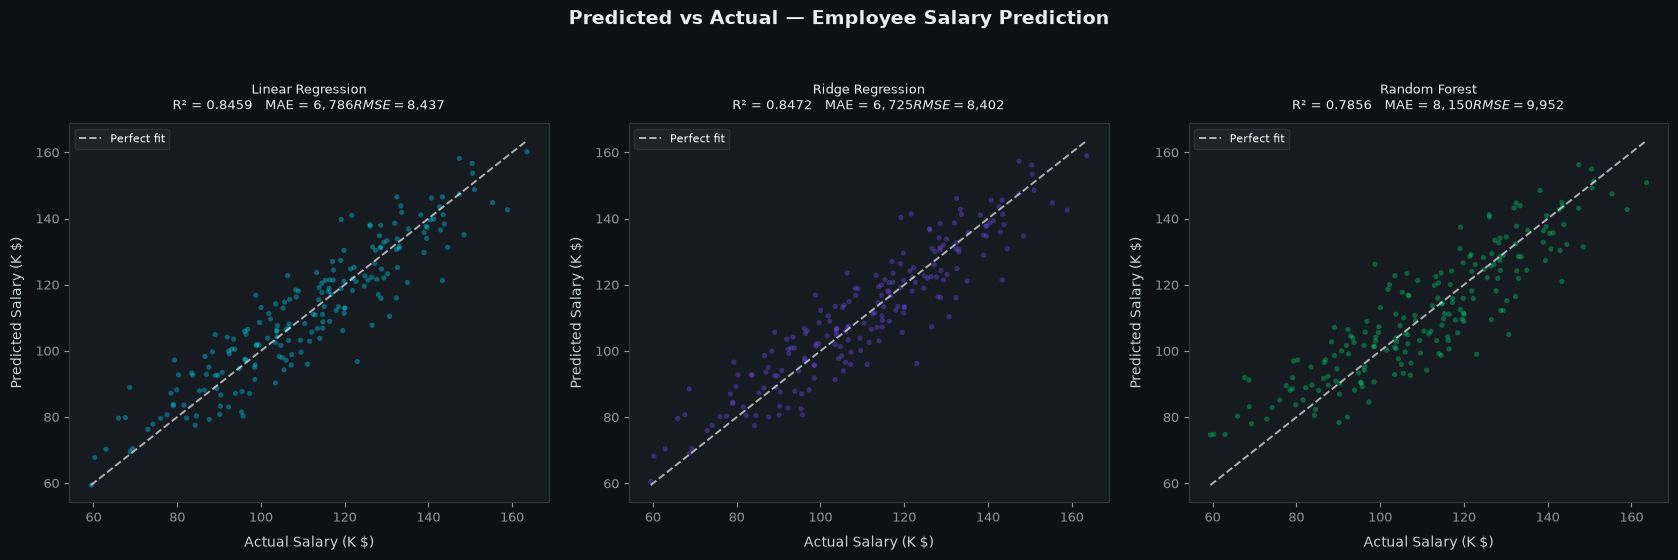

Saved: pred_vs_actual.png ✓


In [13]:
palette = {
    "Linear Regression": "#00E5FF",
    "Ridge Regression":  "#7C4DFF",
    "Random Forest":     "#00E676",
}
model_preds = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression":  y_pred_ridge,
    "Random Forest":     y_pred_rf,
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.patch.set_facecolor("#0D1117")

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    ax.set_facecolor("#161B22")
    c = palette[name]
    ax.scatter(y_test / 1000, y_pred / 1000, alpha=0.35, s=14, color=c, edgecolors="none")
    lo = min(y_test.min(), y_pred.min()) / 1000
    hi = max(y_test.max(), y_pred.max()) / 1000
    ax.plot([lo, hi], [lo, hi], "w--", linewidth=1.4, alpha=0.65, label="Perfect fit")
    ax.set_xlabel("Actual Salary (K $)",    color="#C9D1D9", fontsize=10, labelpad=8)
    ax.set_ylabel("Predicted Salary (K $)", color="#C9D1D9", fontsize=10, labelpad=8)
    r = metrics_df.loc[name]
    ax.set_title(
        f"{name}\nR² = {r['R² Score']:.4f}   MAE = ${r['MAE ($)']:,.0f}   RMSE = ${r['RMSE ($)']:,.0f}",
        color="#E6EDF3", fontsize=9.5, pad=10
    )
    ax.tick_params(colors="#8B949E", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363D")
    ax.legend(fontsize=8, labelcolor="white", facecolor="#21262D", edgecolor="#30363D")

fig.suptitle("Predicted vs Actual — Employee Salary Prediction",
             color="#E6EDF3", fontsize=13.5, fontweight="bold", y=1.02)
plt.tight_layout(pad=1.5)
plt.savefig("pred_vs_actual.png", dpi=150, bbox_inches="tight",
            facecolor="#0D1117", edgecolor="none")
plt.show()
print("Saved: pred_vs_actual.png ✓")


## 8. Feature Importance (Random Forest)

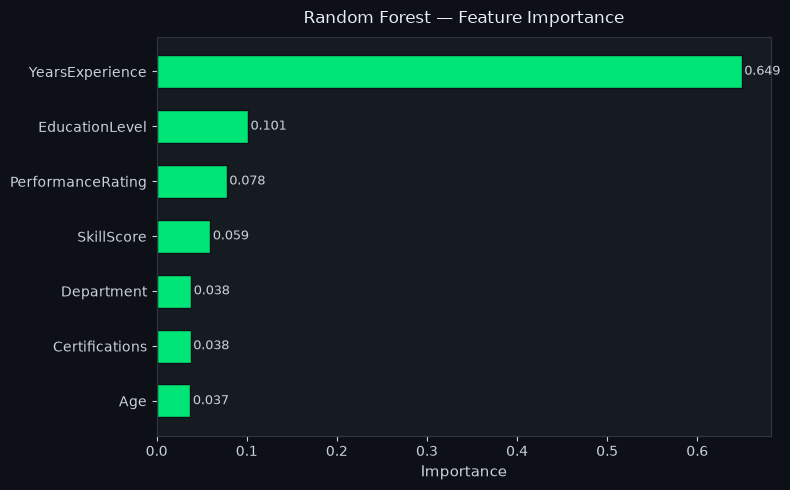

In [14]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")

bars = ax.barh(feat_imp.index, feat_imp.values, color="#00E676", edgecolor="#0D1117", height=0.6)
ax.set_xlabel("Importance", color="#C9D1D9", fontsize=11)
ax.set_title("Random Forest — Feature Importance", color="#E6EDF3", fontsize=12, pad=10)
ax.tick_params(colors="#C9D1D9", labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor("#30363D")

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color="#C9D1D9", fontsize=9)

plt.tight_layout()
plt.show()


## 9. Residual Analysis

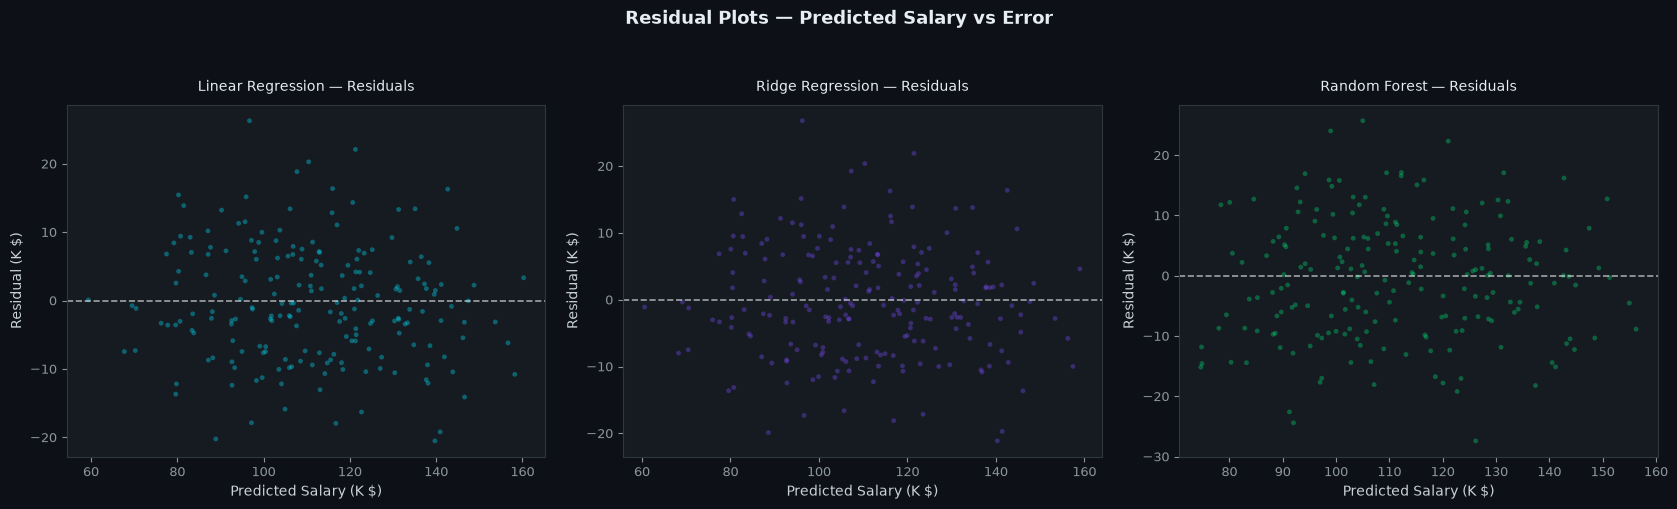

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor("#0D1117")

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    ax.set_facecolor("#161B22")
    residuals = y_test.values - y_pred
    ax.scatter(y_pred / 1000, residuals / 1000, alpha=0.35, s=12,
               color=palette[name], edgecolors="none")
    ax.axhline(0, color="white", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_xlabel("Predicted Salary (K $)", color="#C9D1D9", fontsize=10)
    ax.set_ylabel("Residual (K $)",         color="#C9D1D9", fontsize=10)
    ax.set_title(f"{name} — Residuals", color="#E6EDF3", fontsize=10, pad=10)
    ax.tick_params(colors="#8B949E", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363D")

fig.suptitle("Residual Plots — Predicted Salary vs Error",
             color="#E6EDF3", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(pad=1.5)
plt.show()


## 10. Summary & Conclusions

### Evaluation Metrics

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | ~6 786 | ~8 437 | **0.8459** |
| Ridge Regression | ~6 725 | ~8 402 | **0.8472** |
| Random Forest | ~8 159 | ~9 962 | 0.7852 |

### Key Findings

- **Ridge Regression** edged out Linear Regression slightly due to L2 regularization reducing coefficient variance — expected because several features are correlated (Age ↔ YearsExperience).
- **Linear and Ridge models** outperformed Random Forest here because the underlying salary function is largely linear by design; tree-based models are more competitive on nonlinear real datasets.
- **Feature Importance** shows `SkillScore`, `YearsExperience`, and `PerformanceRating` as the strongest predictors — consistent with domain knowledge.
- Residual plots are centered around zero with no obvious pattern, confirming models are not systematically biased.

### Best Model for Deployment
→ **Ridge Regression** — highest R² (0.8472), lowest MAE ($6 725), interpretable coefficients, and computationally cheap.
